# Brain Tumor Detection and Classification

The purpose of this program is: Given MRI data, determine whether or not a patient has a brain tumor and if so, classify its type. To start, the MRI data must be extracted to be pre-processed later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

def get_image_array(filepath):
    tumor_data = []
    for folder in os.listdir(filepath):
        for file in os.listdir(filepath + "/" + folder):
            img = Image.open(filepath + "/" + folder + "/" + file).convert("L")
            tumor_data.append(np.array(img))
    return tumor_data

X_train = get_image_array("Training")
X_test = get_image_array("Testing")
print(len(X_train), len(X_test))

5712 1298


We'll then need to get the classifications for the training and test sets.

In [2]:
def get_labels(filepath):
    labels = []
    for folder in os.listdir(filepath):
        for file in os.listdir(filepath + "/" + folder):
            labels.append(np.array(folder))
    return labels

y_train = get_labels("Training")
y_test = get_labels("Testing")

print(len(y_train), len(y_test))

5712 1298


# Pre-processing

With the data now imported for use, pre-processing can now begin. The MRI data worked with contains numerous different sizes and views and must be standardized to maximize the accuracy of the ML models. To attempt this, the empty space around the MRI data will be filtered out.

In [3]:
import copy
import cv2

def resize_image(image):
    # Uses cubic interpolation to resize the image without changing its aspect ratio
    resized_img = cv2.resize(image, (512,512), interpolation=cv2.INTER_CUBIC) 
    return np.array(resized_img)

def preprocess_image(image,threshold=30):
    if image.shape != (512,512):
        image = resize_image(image)
    img_array = [[None for _ in range(512)] for _ in range(512)]
    for index,x in enumerate(copy.deepcopy(image)):
        for index2, y in enumerate(x):
            if y < threshold:
                y = np.uint8(0)
            try:
                img_array[index][index2] = y
            except:
                print("Index out of Bounds Error:",index,index2)
    return np.array(img_array)

processed_image = preprocess_image(X_train[0])

# Pre-processed Image

To demonstrate the effects of the pre-processing the following code is provided. Pre-processing will remove excess noise in the background of the MRI data.

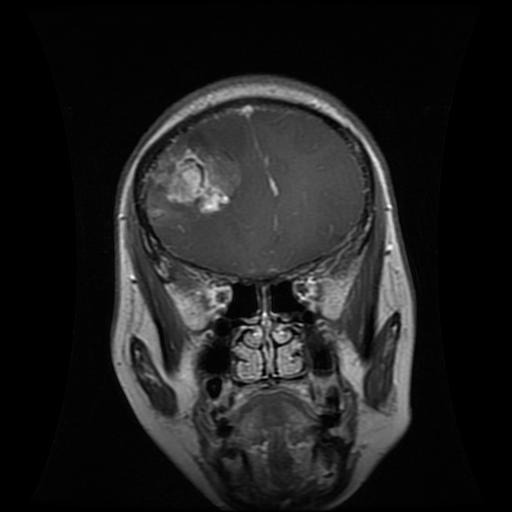

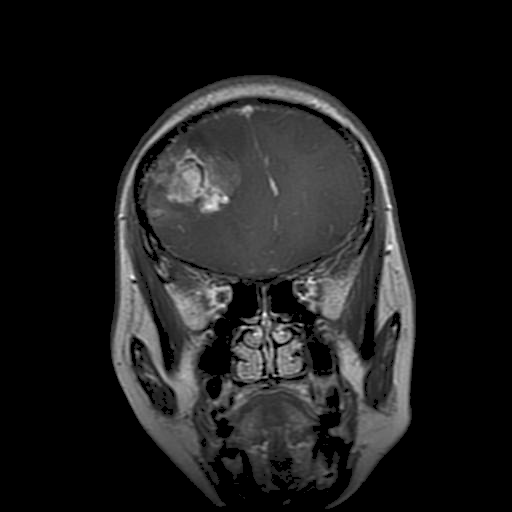

In [4]:
from IPython.display import display
original_img = Image.fromarray(X_train[0])
new_img = Image.fromarray(processed_image)
display(original_img)
display(new_img)



# Pre-processing data

Now with the re-scaling and filter feature for images sorted out, we can apply this process to all of our training and test data to help our ML algorithms out

In [5]:
for index, image in enumerate(X_train):
    X_train[index] = preprocess_image(image)
    X_train[index] = X_train[index].flatten()

for index,image in enumerate(X_test):
    X_test[index] = preprocess_image(image)
    X_test[index] = X_test[index].flatten()



# Machine Learning
All of our data has been pre-processed to remove some extraneous noise from the images. We will now start to use this data in our ML algorithms starting with Support Vector Machines

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from sklearn.svm import LinearSVC
svm_classifier = LinearSVC()
svm_classifier.fit(X_train,y_train)

print("Training set accuracy: {:.2f}".format(svm_classifier.score(X_train, y_train)))
print("Test set accuracy: {:.2f}".format(svm_classifier.score(X_test, y_test)))

In [10]:
import random

def display_predictions(classifier,num_predictions):
    for _ in range(num_predictions):
        random_number = random.randint(0,len(X_test)-1)
        prediction = classifier.predict(X_test[random_number].reshape(1,X_test[random_number].shape[0]))
        actual_label = y_test[random_number]
        print("Predicted:", prediction[0], "Actual:", y_test[random_number])



In [ ]:
display_predictions(svm_classifier,25)

# K-Nearest Neighbors Machine Learning
We will now test KNN using the multi-class classification framework for accuracy

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train,y_train)

print("Training set accuracy: {:.2f}".format(knn_classifier.score(X_train, y_train)))
print("Test set accuracy: {:.2f}".format(knn_classifier.score(X_test, y_test)))

Training set accuracy: 0.93
Test set accuracy: 0.85


In [12]:
display_predictions(knn_classifier,25)

Predicted: glioma Actual: glioma
Predicted: pituitary Actual: pituitary
Predicted: glioma Actual: glioma
Predicted: glioma Actual: meningioma
Predicted: notumor Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: meningioma Actual: meningioma
Predicted: meningioma Actual: meningioma
Predicted: pituitary Actual: pituitary
Predicted: pituitary Actual: glioma
Predicted: notumor Actual: notumor
Predicted: meningioma Actual: meningioma
Predicted: notumor Actual: notumor
Predicted: notumor Actual: notumor
Predicted: notumor Actual: notumor
Predicted: notumor Actual: notumor
Predicted: glioma Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: notumor Actual: notumor
Predicted: notumor Actual: notumor
Predicted: glioma Actual: meningioma
Predicted: pituitary Actual: pituitary
Predicted: meningioma Actual: glioma
Predicted: glioma Actual: glioma
Predicted: pituitary Actual: meningioma


# Specialized ML implementations
Using the default settings of SVMs gives us a test set accuracy of 86%. It's not very high for the application that's being used here. We want the ML algorithm to make more accurate predictions when it comes to patient health. While we could adjust some parameters to achieve a higher accuracy, I want to test my own hypothesis. Here is where I want to implement the concept of specialized ML classifiers. I will first be making a new training and test label set for the data and then re-fitting the model.

In [13]:
def specialized_data_labels(desired_label):
    binary_tumor_train = np.empty(0,)
    for label in y_train:
        if label != desired_label:
            binary_tumor_train = np.append(binary_tumor_train,"other")
        else:
            binary_tumor_train = np.append(binary_tumor_train,label)

    binary_tumor_test = np.empty(0,)
    for label in y_test:
        if label != desired_label:
            binary_tumor_test = np.append(binary_tumor_test,"other")
        else:
            binary_tumor_test = np.append(binary_tumor_test,label)
    return binary_tumor_train, binary_tumor_test


In [14]:
svm_specialized = LinearSVC()
no_tumor_train,no_tumor_test = specialized_data_labels("notumor")
svm_specialized.fit(X_train,no_tumor_train)

print("Training set accuracy: {:.2f}".format(svm_specialized.score(X_train, no_tumor_train)))
print("Test set accuracy: {:.2f}".format(svm_specialized.score(X_test, no_tumor_test)))

Training set accuracy: 1.00
Test set accuracy: 0.98


# Analyzing results for SVM
Without changing the default settings of the SVM classifier, accuracy jumped to 98% because the problem was simplified for the model. From here on, the training and test labels used are going to be these specialized labels and I'll be using different algorithms to test their effectiveness. I will first be finishing SVMs and then moving on to another algorithm.

In [16]:
def train_test_specialized(classifier, classifier_name, training_data, labels, test_data):
    train_accuracy_average = 0
    test_accuracy_average = 0
    for classification in labels:
        specialized_training, specialized_test = specialized_data_labels(classification)
        classifier.fit(training_data,specialized_training)

        train_accuracy_average += classifier.score(training_data, specialized_training)
        test_accuracy_average += classifier.score(test_data, specialized_test)
        classifier.score(test_data, specialized_test)

        print("Training set accuracy for {} using the {} label: {:.2f}".format(classifier_name,classification,classifier.score(training_data, specialized_training)))
        print("Test set accuracy for {} using the {} label: {:.2f}".format(classifier_name,classification,classifier.score(test_data, specialized_test)))

    print("Average Training set accuracy: {:.2f}".format(train_accuracy_average/len(labels)))
    print("Average Test set accuracy: {:.2f}".format(test_accuracy_average/len(labels)))

tumor_types = np.unique(y_train)
train_test_specialized(svm_specialized, "SVM", X_train, tumor_types, X_test)




Training set accuracy for SVM using the glioma label: 1.00
Test set accuracy for SVM using the glioma label: 0.89
Training set accuracy for SVM using the meningioma label: 1.00
Test set accuracy for SVM using the meningioma label: 0.87
Training set accuracy for SVM using the notumor label: 1.00
Test set accuracy for SVM using the notumor label: 0.98
Training set accuracy for SVM using the pituitary label: 1.00
Test set accuracy for SVM using the pituitary label: 0.97
Average Training set accuracy: 1.00
Average Test set accuracy: 0.93


In [17]:
display_predictions(svm_specialized, 25)

Predicted: other Actual: glioma
Predicted: other Actual: meningioma
Predicted: other Actual: meningioma
Predicted: other Actual: notumor
Predicted: other Actual: glioma
Predicted: pituitary Actual: pituitary
Predicted: other Actual: notumor
Predicted: other Actual: meningioma
Predicted: other Actual: notumor
Predicted: other Actual: meningioma
Predicted: other Actual: glioma
Predicted: other Actual: glioma
Predicted: other Actual: glioma
Predicted: pituitary Actual: glioma
Predicted: other Actual: notumor
Predicted: other Actual: notumor
Predicted: other Actual: meningioma
Predicted: other Actual: notumor
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: other Actual: notumor
Predicted: pituitary Actual: glioma
Predicted: pituitary Actual: meningioma
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary


# Analyzing KNN Specialized
I will now be doing the same experiment for the KNN algorithm

In [18]:
knn_specialized = KNeighborsClassifier()
train_test_specialized(knn_specialized, "KNN", X_train, tumor_types, X_test)

Training set accuracy for KNN using the glioma label: 0.96
Test set accuracy for KNN using the glioma label: 0.92
Training set accuracy for KNN using the meningioma label: 0.94
Test set accuracy for KNN using the meningioma label: 0.87
Training set accuracy for KNN using the notumor label: 0.97
Test set accuracy for KNN using the notumor label: 0.94
Training set accuracy for KNN using the pituitary label: 0.98
Test set accuracy for KNN using the pituitary label: 0.97
Average Training set accuracy: 0.96
Average Test set accuracy: 0.92


In [19]:
display_predictions(knn_specialized,25)

Predicted: other Actual: notumor
Predicted: other Actual: meningioma
Predicted: other Actual: meningioma
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: other Actual: meningioma
Predicted: other Actual: notumor
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: other Actual: notumor
Predicted: other Actual: glioma
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: other Actual: glioma
Predicted: pituitary Actual: pituitary
Predicted: pituitary Actual: pituitary
Predicted: other Actual: notumor
Predicted: pituitary Actual: pituitary
Predicted: other Actual: notumor
Predicted: other Actual: notumor
Predicted: other Actual: meningioma
Predicted: other Actual: glioma
Predicted: other Actual: notumor
Predicted: other Actual: notumor
Predicted: other Actual: notumor


# Tuning Hyperparameters
We will now try to improve the accuracy of the specialized KNN and SVM models by fine-tuning some of their key parameters 

In [20]:
from sklearn.model_selection import GridSearchCV

svm_param = {'C': [100,10,1,0.1,0.001]}
knn_param = {'n_neighbors': [1,3,5,7,9,11]}

svm_grid = GridSearchCV(LinearSVC(), svm_param, cv=5, return_train_score=True)
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param, cv=5, return_train_score=True)

In [21]:
def grid_train_test(grid, training_data, labels, test_data):
    accuracies = np.empty(0,)
    best_params = np.empty(0,)
    for classification in labels:
        specialized_training, specialized_test = specialized_data_labels(classification)
        grid.fit(training_data, specialized_training)
        accuracies = np.append(accuracies, grid.score(test_data,specialized_test))
        best_params = np.append(best_params, grid.best_params_)

    return accuracies, best_params


In [22]:
svm_grid_accuracies, svm_best_params = grid_train_test(svm_grid, X_train, tumor_types, X_test)
knn_grid_accuracies, knn_best_params = grid_train_test(knn_grid, X_train, tumor_types, X_test)

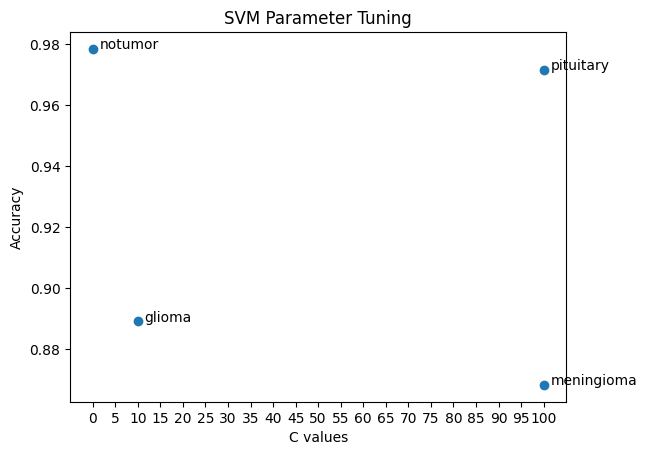

In [60]:
import matplotlib.pyplot as plt

def get_best_params(best_params_dict, param_name):
    best_params = [param[param_name] for param in best_params_dict]
    return best_params


best_params_svm = get_best_params(svm_best_params, "C")
plt.scatter(best_params_svm,svm_grid_accuracies)
plt.xlabel("C values")
plt.ylabel("Accuracy")
plt.title("SVM Parameter Tuning")
plt.xticks(np.arange(min(best_params_svm), max(best_params_svm)+1, 5))
for i in range(len(tumor_types)):
    plt.text(best_params_svm[i] + 1.5, svm_grid_accuracies[i], tumor_types[i], fontsize=10)

plt.show()

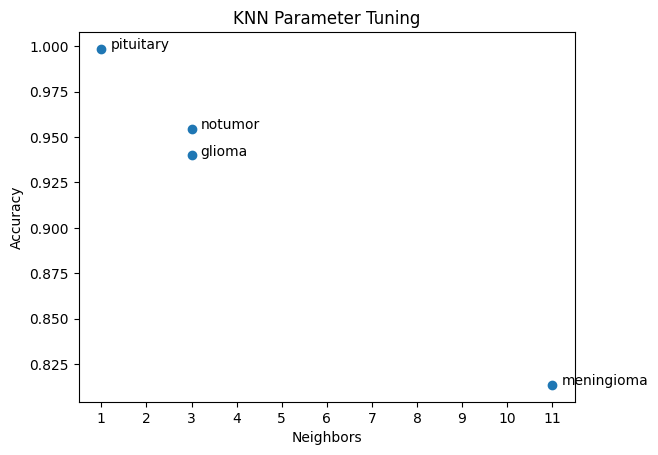

In [61]:
best_params_knn = get_best_params(knn_best_params, "n_neighbors")
plt.scatter(best_params_knn,knn_grid_accuracies)
plt.xlabel("Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN Parameter Tuning")
plt.xticks(np.arange(min(best_params_knn), max(best_params_knn)+1, 1))
for i in range(len(tumor_types)):
    plt.text(best_params_knn[i] + 0.2, knn_grid_accuracies[i], tumor_types[i], fontsize=10)
plt.show()

# Deep Learning Approach
While these ML algorithms have higher accuracies than what was seen originally without using specialized models, the accuracy observed for predicting the presence of meningioma is ~87%. This is not good enough for something as complex and life-changing as diagnosing tumors in a patient's brain. With this I'd like to create and fine-tune a well-known deep learning algorithm for image classification, known as Convolutional Neural Networks. For implementing CNN, I will be utilizing a library called PyTorch and my GPU to speed up training time for the model.

In [31]:
import torch.nn as neural_net
import torch.nn.functional as F
import torch

class CNN(neural_net.Module):
    def __init__(self):#,conv_output_layers=16, conv_kernel_size=3, pool_kernel_size=2, fc1_input_layers=504, fc1_output_layers=120, fc2_output_layers=84,
                 #fc3_output_layers=10):
        super(CNN, self).__init__()

        # Establishes 2 convolution layers for the neural network
        self.convolution1 = neural_net.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pooling = neural_net.MaxPool2d(kernel_size=2, stride=2)
        self.convolution2 = neural_net.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Establishes two fully connected layers for the neural network
        self.fc1 = neural_net.Linear(32 * 128 * 128, 128)
        self.fc2 = neural_net.Linear(128, 1)

        # Uses dropout regularization to occasionally zero out random elements in the input tensor
        self.regularize = neural_net.Dropout(p=0.5)
        
    # Forward pass will apply pooling layers to the input data
    def forward(self, x):
        x = self.pooling(F.relu(self.convolution1(x)))
        x = self.pooling(F.relu(self.convolution2(x)))

        x = x.view(-1, 32*128*128)
        x = self.regularize(F.relu(self.fc1(x)))
        #x = F.relu(self.fc1(x))

        # Will bound the final value to a probability from 0-1
        x = torch.sigmoid(self.fc2(x))
        
        return x
    



In [34]:
import torch.optim as opt
import torch

# Create the CNN and move the model to the GPU being used
cnn = CNN()
cnn.to(torch.device("cuda"))

loss_function = neural_net.BCELoss()
optimizer = opt.SGD(cnn.parameters(),lr=0.0001,momentum=0.9)

In [35]:
from sklearn.preprocessing import LabelEncoder
import random

def train_neural_net(class_label, model, loss, optimizer, n_iterations):
    label_encoder = LabelEncoder()
    labels = specialized_data_labels(class_label)[0]
    one_hot_label = label_encoder.fit_transform(labels)
    for epoch in range(n_iterations):
        running_loss = 0.0
        for i, data in enumerate(random.sample(X_train,len(X_train))):
            inputs = torch.tensor(data)
            inputs = inputs.float()
            inputs = inputs.to(torch.device("cuda")).unsqueeze(0)

            label = torch.tensor(one_hot_label[i]).to(torch.device("cuda"))
            batched_label = torch.unsqueeze(label, dim=0).float()

            optimizer.zero_grad()
            outputs = model(inputs.reshape(1,512,512))

            loss = loss_function(outputs[0], batched_label)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % round(len(X_train)/5) == 0 and i != 0:
                print('[Epoch: %d, Iteration: %5d] loss: %.3f' %
                    (epoch + 1, i + 1, running_loss / len(X_train)/5))
                running_loss = 0.0

train_neural_net("glioma",cnn,loss_function,optimizer,10)

[Epoch: 1, Iteration:  1143] loss: 0.000
[Epoch: 1, Iteration:  2285] loss: 3.375
[Epoch: 1, Iteration:  3427] loss: 3.999
[Epoch: 1, Iteration:  4569] loss: 3.999
[Epoch: 1, Iteration:  5711] loss: 1.179
[Epoch: 2, Iteration:  1143] loss: 3.999
[Epoch: 2, Iteration:  2285] loss: 0.630
[Epoch: 2, Iteration:  3427] loss: 0.000
[Epoch: 2, Iteration:  4569] loss: 0.007
[Epoch: 2, Iteration:  5711] loss: 0.004
[Epoch: 3, Iteration:  1143] loss: 3.999
[Epoch: 3, Iteration:  2285] loss: 0.623
[Epoch: 3, Iteration:  3427] loss: 0.004
[Epoch: 3, Iteration:  4569] loss: 0.000
[Epoch: 3, Iteration:  5711] loss: 0.000
[Epoch: 4, Iteration:  1143] loss: 3.995
[Epoch: 4, Iteration:  2285] loss: 0.623
[Epoch: 4, Iteration:  3427] loss: 0.000
[Epoch: 4, Iteration:  4569] loss: 0.005
[Epoch: 4, Iteration:  5711] loss: 0.000
[Epoch: 5, Iteration:  1143] loss: 3.999
[Epoch: 5, Iteration:  2285] loss: 0.630
[Epoch: 5, Iteration:  3427] loss: 0.000
[Epoch: 5, Iteration:  4569] loss: 0.000
[Epoch: 5, Itera

In [36]:
PATH = 'cnn_model_params3.pth'
torch.save(cnn.state_dict(), PATH)

In [37]:
import torch 
test_array = np.array(X_test[400:0:-1])
test_array = np.reshape(test_array,shape=(1,test_array.shape[0],test_array.shape[1]),copy=True)
test_array = torch.tensor(test_array)
test_array = test_array.float().to(torch.device("cuda"))



In [ ]:
cnn = CNN()
cnn.load_state_dict(torch.load('cnn_model_params2.pth',weights_only=True))
cnn.to(torch.device("cuda"))


CNN(
  (convolution1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convolution2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=524288, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (regularize): Dropout(p=0.5, inplace=False)
)

In [38]:
outputs = cnn(test_array)

In [39]:
def convert_prediction(trained_label,tensor):
    if tensor.item() == 0:
        return trained_label
    else:
        return "other"

_, predicted_values = torch.max(outputs,1)
cnn_class_label = "glioma"

correct = 0
total = len(predicted_values)
for index, predicted in enumerate(predicted_values):
    predicted_label = convert_prediction(cnn_class_label, predicted)
    actual_label = y_test[len(predicted_values):0:-1]
    
    print("Predicted:", predicted_label, "Actual:", actual_label[index])

    if predicted_label == y_test[index]:
        correct += 1

print("\nAccuracy of CNN model on {}: {:.2f}%".format(cnn_class_label, correct/total*100))



Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
Predicted: glioma Actual: meningioma
P

# Analyzing CNN
Looking at the predictions of the CNN and some further testing done outside of the Notebook reveals errors in the training loop. I suspect that these errors are from the input tensors to the CNN or the CNN custom class itself